# 7. Programación Orientada a Objetos (OOP) en Python

## Objetivos

1. Comprender los conceptos fundamentales de OOP: clases, objetos, atributos y métodos.
2. Implementar encapsulamiento, herencia, polimorfismo y abstracción.
3. Dominar los métodos especiales (*dunder*) para crear objetos expresivos.
4. Organizar el código en módulos y paquetes.
5. Aplicar patrones de diseño: Singleton, Factory, Strategy y Observer.
6. Modelar sistemas físicos con OOP.

---

## Mapa conceptual del tema

```
OOP
├── 1. Conceptos básicos       → clase, objeto, atributo, método, self
├── 2. Métodos especiales      → __init__, __str__, __add__, __len__, ...
├── 3. Encapsulamiento         → público, _protegido, __privado, @property
├── 4. Herencia & Polimorfismo → super(), ABC, @abstractmethod
├── 5. Patrones de diseño      → Singleton, Factory, Strategy, Observer
├── 6. Módulos y paquetes      → import, __init__.py
└── 7. Buenas prácticas        → SOLID, composición, docstrings
```

> **Filosofía clave:** en OOP modelamos el mundo como *objetos* que tienen *estado* (atributos) y *comportamiento* (métodos). El código resultante se parece más al dominio del problema —física, banco, simulación— y es más fácil de leer, mantener y extender.

---
## 1. Conceptos básicos: clase, objeto, atributo y método

### 1.1 ¿Por qué OOP? La motivación

Imagina que necesitas representar vectores matemáticos en un programa.
La forma más simple es usar listas de Python, pero enseguida aparecen problemas:

- **¿Cómo sumamos dos vectores?** Tenemos que recordar llamar a `sumar_vectores(a, b)`.
- **¿Qué pasa si alguien pasa una cadena de texto en lugar de un vector?** No hay validación.
- **¿Cómo sabemos qué funciones pertenecen a los vectores y cuáles no?** Todo está mezclado.

Con OOP estos tres problemas desaparecen porque los datos y las funciones viven **juntos** dentro de un objeto.

In [1]:
# ── SIN OOP ──────────────────────────────────────────────────────────────────
# Los datos son listas sueltas. Las funciones son independientes.
# Nada une v1 con sumar_vectores: alguien podría llamar sumar_vectores('hola', 5)

v1 = [1, 2, 3]
v2 = [4, 5, 6]

def sumar_vectores(a, b):
    return [a[i] + b[i] for i in range(len(a))]

def magnitud(v):
    return sum(x**2 for x in v) ** 0.5

print('Suma:      ', sumar_vectores(v1, v2))
print('Magnitud v1:', round(magnitud(v1), 4))

# Problema visible: nadie impide este error en tiempo de escritura:
# sumar_vectores([1,2], [1,2,3])  <- listas de distinto tamaño, crashea
# La responsabilidad de usarlo bien queda en el programador, no en el código.

Suma:       [5, 7, 9]
Magnitud v1: 3.7417


### 1.2 Anatomía de una clase — la plantilla

Una **clase** es como un **plano de construcción**.
El plano describe cómo debe ser una casa (cuántas habitaciones, qué materiales).
Pero el plano en sí no es una casa: a partir de él puedes construir miles de casas diferentes.

En OOP:
- El **plano** es la clase.
- Cada **casa construida** es un objeto (también llamado *instancia*).

```python
class NombreClase:           # 1. Palabra clave 'class' + nombre en CamelCase
    'Docstring: describe la clase.'  # 2. Documentación (opcional pero recomendada)

    def __init__(self, ...): # 3. Constructor: se ejecuta al crear el objeto
        self.atributo = ...  # 4. self.x guarda el estado propio del objeto

    def metodo(self):        # 5. Métodos: funciones que pertenecen a la clase
        ...
```

| Término | Analogía física | Significado en Python |
|---------|-----------------|----------------------|
| **Clase** | Fórmula matemática | Plantilla que define estructura y comportamiento |
| **Objeto / Instancia** | Número concreto que sigue la fórmula | Ejemplar creado a partir de la clase |
| **Atributo** | Variable de estado: posición, velocidad | Variable que pertenece a *ese* objeto |
| **Método** | Operación: calcular energía, sumar | Función que opera sobre el objeto |
| **`self`** | «yo mismo el objeto» | Referencia al objeto que está llamando al método |

### 1.3 Ejemplo paso a paso — Clase `Vector`

Vamos a construir la clase `Vector` desde cero. Cada comentario en el código
explica **por qué** se escribe de esa forma, no solo **qué** hace.

In [2]:
class Vector:
    """
    Representa un vector matemático en 2D o 3D.

    Por qué usar una clase:
    - Los datos (x, y, z) y las operaciones (sumar, magnitud) viven juntos.
    - Podemos crear muchos vectores independientes, cada uno con su propio estado.
    - El código que usa Vector se parece al álgebra: v1.sumar(v2), v1.magnitud().
    """

    # ── Constructor (__init__) ────────────────────────────────────────────────
    # __init__ se llama automáticamente cuando escribes Vector(1, 2, 3).
    # 'self' es el objeto recién creado; aquí le asignamos sus atributos.
    # z=0 es un valor por defecto: Vector(1,2) crea un vector 2D.
    def __init__(self, x, y, z=0):
        self.x = x   # self.x guarda la componente x EN ESTE objeto
        self.y = y   # cada Vector tiene su propio self.x, self.y, self.z
        self.z = z   # si no se da z, es 0 (vector 2D)

    # ── Método normal ─────────────────────────────────────────────────────────
    # 'otro' es otro Vector. Python no lo exige explícitamente, pero el
    # docstring documenta qué tipo se espera.
    def sumar(self, otro):
        """Devuelve un NUEVO Vector que es la suma componente a componente."""
        # Creamos un nuevo objeto; no modificamos self ni otro.
        # Este patrón (devolver un nuevo objeto) es común en matemáticas.
        return Vector(self.x + otro.x, self.y + otro.y, self.z + otro.z)

    def magnitud(self):
        """Calcula el módulo: |v| = sqrt(x^2 + y^2 + z^2)."""
        return (self.x**2 + self.y**2 + self.z**2) ** 0.5

    # ── Método especial __str__ ───────────────────────────────────────────────
    # Sin __str__, print(v) mostraría algo como: <__main__.Vector object at 0x...>
    # Al definir __str__ controlamos cómo se ve el objeto.
    def __str__(self):
        """Representación legible: se llama con print(v) o str(v)."""
        return f"Vector({self.x}, {self.y}, {self.z})"


# ── Crear objetos (instanciar la clase) ──────────────────────────────────────
# Aquí Python llama a Vector.__init__(v1, 1, 2, 3) automáticamente
v1 = Vector(1, 2, 3)
v2 = Vector(4, 5, 6)

print("v1:", v1)              # llama a __str__  → Vector(1, 2, 3)
print("v2:", v2)
print("Suma:", v1.sumar(v2))  # llama a sumar; devuelve Vector(5, 7, 9)
print("|v1|:", round(v1.magnitud(), 4))
print("Tipo:", type(v1))      # <class '__main__.Vector'>

# Acceder a atributos individuales
print(f"Componente x de v1: {v1.x}")

v1: Vector(1, 2, 3)
v2: Vector(4, 5, 6)
Suma: Vector(5, 7, 9)
|v1|: 3.7417
Tipo: <class '__main__.Vector'>
Componente x de v1: 1


### 1.4 `self` explicado con detalle

`self` es simplemente la forma en que el método sabe **de qué objeto hablar**.

Cuando escribes `v1.sumar(v2)`, Python lo convierte internamente en:
```python
Vector.sumar(v1, v2)   # self=v1, otro=v2
```

Dentro del método, `self.x` significa «la componente x de v1».
Si llamas `v2.sumar(v1)`, entonces `self.x` sería «la componente x de v2».

**Regla de oro:** `self` siempre es el primer parámetro de cualquier método,
pero **nunca lo escribes cuando llamas al método**. Python lo pasa solo.

```python
# Cómo lo escribe el usuario:
v1.sumar(v2)

# Cómo lo ve Python internamente:
Vector.sumar(v1, v2)
#            ^^^--- esto es 'self' dentro del método
```

### 1.5 Atributos de clase vs. atributos de instancia

Hay dos lugares donde puedes definir variables en una clase:

| | Atributo de **clase** | Atributo de **instancia** |
|-|-----------------------|--------------------------|
| **Dónde se define** | Directamente dentro de la clase, fuera de métodos | Dentro de `__init__` usando `self.` |
| **Quién lo posee** | La clase entera (compartido por todos los objetos) | Cada objeto tiene el suyo propio |
| **Para qué sirve** | Contadores, constantes, valores por defecto globales | Estado particular de cada objeto |
| **Cómo se accede** | `MiClase.atributo` o `self.atributo` | Solo `self.atributo` |

El siguiente ejemplo usa una clase de física para ilustrar ambos:

In [3]:
class Particula:
    """
    Partícula subatómica. Ilustra la diferencia entre atributos
    de clase (compartidos) y de instancia (únicos por objeto).
    """

    # ── Atributo de CLASE ─────────────────────────────────────────────────────
    # Existe UNA sola vez, pertenece a Particula, no a un objeto concreto.
    # Se incrementa cada vez que creamos una partícula nueva.
    contador = 0

    def __init__(self, nombre, masa, carga):
        # ── Atributos de INSTANCIA ────────────────────────────────────────────
        # Cada objeto tiene sus propios nombre, masa y carga.
        # El electrón tiene masa 9.109e-31 kg; el protón tiene 1.673e-27 kg.
        self.nombre = nombre
        self.masa   = masa    # kg
        self.carga  = carga   # Coulombs

        # Actualizamos el contador de la CLASE cada vez que se crea un objeto
        Particula.contador += 1

    def energia_reposo(self):
        """Calcula la energía en reposo con E = mc² (c ≈ 3×10⁸ m/s)."""
        c = 3e8
        return self.masa * c**2

    def __str__(self):
        return f"{self.nombre}(m={self.masa:.2e} kg, q={self.carga:+.2e} C)"


# Creamos dos partículas distintas
e = Particula("Electron", 9.109e-31, -1.602e-19)
p = Particula("Proton",   1.673e-27, +1.602e-19)

print(e)  # Estado del electrón
print(p)  # Estado del protón

# El contador es de la CLASE; se incrementó con cada objeto creado
print(f"Partículas creadas: {Particula.contador}")  # 2

# Cada objeto tiene su propia energía (masas distintas)
print(f"E reposo electrón: {e.energia_reposo():.3e} J")
print(f"E reposo protón:   {p.energia_reposo():.3e} J")

# Los atributos de instancia son independientes entre objetos
print(f"\ne.nombre = {e.nombre}  (solo del electrón)")
print(f"p.nombre = {p.nombre}   (solo del protón)")

Electron(m=9.11e-31 kg, q=-1.60e-19 C)
Proton(m=1.67e-27 kg, q=+1.60e-19 C)
Partículas creadas: 2
E reposo electrón: 8.198e-14 J
E reposo protón:   1.506e-10 J

e.nombre = Electron  (solo del electrón)
p.nombre = Proton   (solo del protón)


---
## 2. Métodos especiales (*dunder*) y sobrecarga de operadores

### 2.1 ¿Qué son los métodos dunder?

*Dunder* viene de *double underscore* (doble guión bajo).
Son métodos con nombre `__algo__` que Python llama **automáticamente**
cuando usas ciertas operaciones del lenguaje.

Por ejemplo, cuando escribes `v1 + v2`, Python busca si el objeto tiene un método `__add__`
y lo llama. Esto permite que tus objetos se **comporten como tipos nativos** de Python.

Piénsalo así: cuando haces `2 + 3`, Python llama internamente a `int.__add__(2, 3)`.
Si defines `__add__` en tu clase, tu objeto puede sumarse igual que un entero.

### 2.2 Tabla de métodos especiales más usados

| Método dunder | Se activa cuando escribes... | Ejemplo de uso |
|---------------|------------------------------|----------------|
| `__init__` | `Clase(args)` | `v = Vector(1,2,3)` |
| `__str__` | `print(obj)` o `str(obj)` | `print(v)` |
| `__repr__` | `repr(obj)` o en el intérprete | `v` (sin print) |
| `__len__` | `len(obj)` | `len(v)` |
| `__add__` | `obj + otro` | `v1 + v2` |
| `__sub__` | `obj - otro` | `v1 - v2` |
| `__mul__` | `obj * escalar` | `v * 3` |
| `__rmul__` | `escalar * obj` | `3 * v` |
| `__truediv__` | `obj / escalar` | `v / 2` |
| `__neg__` | `-obj` | `-v` |
| `__eq__` | `obj == otro` | `v1 == v2` |
| `__abs__` | `abs(obj)` | `abs(v)` |
| `__getitem__` | `obj[i]` | `v[0]` |
| `__iter__` | `for x in obj` | `for c in v` |
| `__contains__` | `x in obj` | `3 in v` |

### 2.3 `__str__` vs `__repr__` — ¿cuál es la diferencia?

- **`__str__`** → representación *amigable para el usuario*. Se usa con `print()`.
- **`__repr__`** → representación *técnica para el desarrollador*. Debería ser reproducible:
  idealmente, `eval(repr(obj))` devolvería un objeto igual.

```python
v = Vector(1, 2, 3)
str(v)   → '(1, 2, 3)'          # legible
repr(v)  → 'Vector(1, 2, 3)'   # se puede copiar y pegar para recrear el objeto
```

**Regla práctica:** si solo defines uno, define `__repr__`. Python usará `__repr__`
como alternativa de `__str__` si `__str__` no está definido.

### 2.4 `__rmul__` — ¿por qué necesitamos dos métodos para multiplicar?

Cuando escribes `v * 3`, Python llama a `v.__mul__(3)` → OK.

Cuando escribes `3 * v`, Python primero intenta `int.__mul__(3, v)` → falla
porque `int` no sabe operar con `Vector`. Entonces Python prueba `v.__rmul__(3)` → OK.

Sin `__rmul__`, `3 * v` daría error. Con él, la multiplicación es **conmutativa**.

### 2.5 Ejemplo completo — `Vector` con todos los operadores

In [ ]:
import math

class Vector:
    """
    Vector 2D/3D con operadores aritméticos completos.
    Cada método dunder permite usar la sintaxis natural de Python.
    """

    def __init__(self, x, y, z=0):
        self.x, self.y, self.z = x, y, z

    # ── Representación ───────────────────────────────────────────────────────
    def __str__(self):
        """Para el usuario: print(v) → '(1, 2, 3)'."""
        return f"({self.x}, {self.y}, {self.z})"

    def __repr__(self):
        """Para el desarrollador: repr(v) → 'Vector(1, 2, 3)' (reproducible)."""
        return f"Vector({self.x!r}, {self.y!r}, {self.z!r})"

    # ── Aritmética ────────────────────────────────────────────────────────────
    def __add__(self, o):  return Vector(self.x+o.x, self.y+o.y, self.z+o.z)
    def __sub__(self, o):  return Vector(self.x-o.x, self.y-o.y, self.z-o.z)
    def __neg__(self):     return Vector(-self.x, -self.y, -self.z)  # -v

    def __mul__(self, k):  # v * escalar
        return Vector(self.x*k, self.y*k, self.z*k)

    def __rmul__(self, k): # escalar * v  (necesario para conmutatividad)
        return self.__mul__(k)

    def __truediv__(self, k):  # v / escalar
        if k == 0: raise ZeroDivisionError("No se puede dividir por cero.")
        return Vector(self.x/k, self.y/k, self.z/k)

    # ── Comparación y magnitud ────────────────────────────────────────────────
    def __eq__(self, o):   # v1 == v2 (usa isclose para evitar errores de punto flotante)
        return (math.isclose(self.x,o.x) and math.isclose(self.y,o.y) and math.isclose(self.z,o.z))

    def __abs__(self):     # abs(v) → módulo del vector
        return math.sqrt(self.x**2 + self.y**2 + self.z**2)

    def __len__(self):     # len(v) → 2 si es 2D, 3 si es 3D
        return 2 if self.z == 0 else 3

    # ── Métodos geométricos (no son dunder, son métodos normales) ─────────────
    def producto_punto(self, o):
        """Producto escalar: v1·v2 = x1x2 + y1y2 + z1z2."""
        return self.x*o.x + self.y*o.y + self.z*o.z

    def producto_cruz(self, o):
        """Producto vectorial v1xv2 (resultado es un vector perpendicular a ambos)."""
        return Vector(self.y*o.z - self.z*o.y,
                      self.z*o.x - self.x*o.z,
                      self.x*o.y - self.y*o.x)

    def normalizar(self):
        """Devuelve el vector unitario (misma dirección, módulo=1)."""
        mag = abs(self)  # llama a __abs__
        if mag == 0: raise ValueError("El vector cero no tiene dirección.")
        return self / mag  # llama a __truediv__


# ── Pruebas con salida comentada ─────────────────────────────────────────────
v1 = Vector(1, 2, 3)
v2 = Vector(4, 5, 6)

print("v1 =     ", v1)            # usa __str__
print("repr(v1):", repr(v1))      # usa __repr__
print("v1 + v2 =", v1 + v2)       # usa __add__
print("v1 - v2 =", v1 - v2)       # usa __sub__
print("v1 * 3  =", v1 * 3)        # usa __mul__
print("3 * v1  =", 3 * v1)        # usa __rmul__  ← sin esto daría error
print("v1 /2  =", v1 / 2)        # usa __truediv__
print("-v1     =", -v1)           # usa __neg__
print("|v1|    =", round(abs(v1),4))  # usa __abs__
print("v1==v1  =", v1 == v1)      # usa __eq__
print("v1·v2   =", v1.producto_punto(v2))
print("v1xv2   =", v1.producto_cruz(v2))
vn = v1.normalizar()
print("v1 norm =", vn, "  |vn|=", round(abs(vn),8), "(debe ser 1.0)")
print("len(v1) =", len(v1))       # usa __len__  → 3 (vector 3D)

v1 =      (1, 2, 3)
repr(v1): Vector(1, 2, 3)
v1 + v2 = (5, 7, 9)
v1 - v2 = (-3, -3, -3)
v1 * 3  = (3, 6, 9)
3 * v1  = (3, 6, 9)
v1 /2  = (0.5, 1.0, 1.5)
-v1     = (-1, -2, -3)
|v1|    = 3.7417
v1==v1  = True
v1·v2   = 32
v1xv2   = (-3, 6, -3)
v1 norm = (0.2672612419124244, 0.5345224838248488, 0.8017837257372732)   |vn|= 1.0 (debe ser 1.0)
len(v1) = 3


### 2.6 Ejemplo — `MiLista`: objeto que se comporta como una lista

Este ejemplo muestra cómo hacer que un objeto personalizado soporte
las mismas operaciones que una lista de Python: acceso por índice,
`len()`, el bucle `for`, el operador `in`, etc.

Esto es útil cuando quieres una lista con comportamiento adicional,
como filtrado automático o validación al insertar.

In [5]:
class MiLista:
    """
    Lista personalizada que demuestra los métodos de secuencia.
    Envuelve una lista Python y añade el método filtrar().
    """

    def __init__(self, elementos=None):
        # Guardamos los datos en un atributo privado por convención (_)
        self._datos = list(elementos) if elementos else []

    # Estos dunder hacen que MiLista se comporte como una secuencia:
    def __len__(self):           # len(ml)        → número de elementos
        return len(self._datos)

    def __getitem__(self, i):    # ml[i]           → acceso por índice
        return self._datos[i]

    def __setitem__(self, i, v): # ml[i] = valor   → asignación por índice
        self._datos[i] = v

    def __delitem__(self, i):    # del ml[i]       → borrar por índice
        del self._datos[i]

    def __contains__(self, x):  # x in ml         → búsqueda
        return x in self._datos

    def __iter__(self):          # for x in ml     → iteración
        return iter(self._datos)

    def __add__(self, otro):     # ml1 + ml2       → concatenar
        return MiLista(self._datos + list(otro))

    def __str__(self):           # print(ml)
        return f"MiLista{self._datos}"

    def __repr__(self):
        return f"MiLista({self._datos!r})"

    # Método personalizado que no existe en listas normales
    def filtrar(self, condicion):
        """
        Devuelve una NUEVA MiLista con los elementos que cumplen condicion.
        condicion debe ser una función (o lambda) que devuelva True/False.
        """
        return MiLista([x for x in self._datos if condicion(x)])


# ── Pruebas ──────────────────────────────────────────────────────────────────
ml = MiLista([10, 20, 30, 40, 50])
print("Lista:", ml)         # usa __str__
print("len:", len(ml))      # usa __len__ → 5
print("ml[1]:", ml[1])      # usa __getitem__ → 20
print("30 in ml:", 30 in ml) # usa __contains__ → True

print("Iterar:", end=" ")
for x in ml:               # usa __iter__
    print(x, end=" ")
print()

# filtrar con una función lambda
grandes = ml.filtrar(lambda x: x > 25)
print("Mayores de 25:", grandes)

ml2 = MiLista([60, 70])
print("Concatenada:", ml + ml2)  # usa __add__

Lista: MiLista[10, 20, 30, 40, 50]
len: 5
ml[1]: 20
30 in ml: True
Iterar: 10 20 30 40 50 
Mayores de 25: MiLista[30, 40, 50]
Concatenada: MiLista[10, 20, 30, 40, 50, 60, 70]


---
## 3. Encapsulamiento

### 3.1 ¿Qué es encapsular?

Encapsular significa **ocultar los detalles internos** de un objeto
y ofrecer solo una interfaz controlada para interactuar con él.

**Analogía:** un coche tiene el motor encapsulado bajo el capó.
Tú interactúas con el coche a través del volante, los pedales y el cambio de marchas.
No necesitas (ni debes) tocar directamente el motor para conducir.

Del mismo modo, una clase expone **métodos públicos** (el volante y los pedales)
y oculta sus **datos internos** (el motor).

### 3.2 Los tres niveles de acceso en Python

Python no tiene acceso prohibido de verdad (a diferencia de Java o C++).
En su lugar usa **convenciones de nombre** que los desarrolladores respetan:

| Prefijo | Nombre | Acceso esperado | Ejemplo |
|---------|--------|-----------------|---------|
| `atributo` | **Público** | Desde cualquier lugar | `self.numero` |
| `_atributo` | **Protegido** | Solo desde la clase y sus subclases | `self._titular` |
| `__atributo` | **Privado** | Solo dentro de la clase (Python aplica *name mangling*) | `self.__saldo` |

**¿Qué es *name mangling*?**
Cuando defines `self.__saldo` en la clase `CuentaBancaria`, Python lo renombra internamente
a `_CuentaBancaria__saldo`. Así, si alguien escribe `cuenta.__saldo` desde fuera,
obtiene un `AttributeError`. El atributo sigue existiendo, pero con un nombre distinto.

### 3.3 `@property` — getters y setters elegantes

En otros lenguajes (Java, C++) se acostumbra escribir métodos `get_x()` y `set_x()`.
Python tiene una forma más elegante: el decorador `@property`.

Un `@property` te permite **acceder a un atributo como si fuera público**
pero por dentro ejecuta código (validación, conversión, etc.):

```python
c.titular          # parece acceso directo, pero llama al getter
c.titular = 'Ana'  # parece asignación directa, pero llama al setter
```

Ventaja: si luego necesitas añadir validación, cambias solo el setter
y **ningún código externo necesita cambiar**.

In [6]:
class CuentaBancaria:
    """
    Cuenta bancaria con los tres niveles de encapsulamiento.

    Atributos:
        numero   (público):    cualquiera puede leer/escribir
        _titular (protegido):  por convención, no tocar desde fuera
        __saldo  (privado):    solo modificable via depositar() y retirar()
    """

    def __init__(self, numero, titular, saldo=0.0):
        self.numero   = numero     # público: acceso libre
        self._titular = titular    # protegido: guión bajo = convención
        self.__saldo  = saldo      # privado: doble guión bajo = name mangling

    # ── @property: getter ─────────────────────────────────────────────────────
    # El decorador @property convierte el método en un «atributo inteligente».
    # Desde fuera se usa como: c.titular  (sin paréntesis)
    @property
    def titular(self):
        """Getter: devuelve el nombre del titular."""
        return self._titular

    # ── @<nombre>.setter: setter ──────────────────────────────────────────────
    # Se activa cuando haces: c.titular = 'Ana'
    # Aquí añadimos validación: no aceptamos nombres vacíos.
    @titular.setter
    def titular(self, nuevo):
        """Setter: valida antes de asignar."""
        if not nuevo or not nuevo.strip():
            raise ValueError("El nombre del titular no puede estar vacío.")
        self._titular = nuevo.strip()

    # ── @property de solo lectura (sin setter) ────────────────────────────────
    # El saldo no se puede asignar directamente desde fuera.
    # Solo se modifica a través de depositar() y retirar().
    @property
    def saldo(self):
        """Getter de solo lectura: el saldo no se puede asignar directamente."""
        return self.__saldo

    # ── Métodos que controlan cómo cambia el saldo ────────────────────────────
    def depositar(self, cantidad):
        """El único camino para aumentar el saldo."""
        if cantidad <= 0:
            raise ValueError("La cantidad a depositar debe ser positiva.")
        self.__saldo += cantidad
        print(f"  Depósito +${cantidad:.2f} → saldo: ${self.__saldo:.2f}")

    def retirar(self, cantidad):
        """El único camino para disminuir el saldo."""
        if cantidad <= 0:
            raise ValueError("La cantidad a retirar debe ser positiva.")
        if cantidad > self.__saldo:
            raise ValueError(f"Fondos insuficientes (saldo: ${self.__saldo:.2f}).")
        self.__saldo -= cantidad
        print(f"  Retiro   -${cantidad:.2f} → saldo: ${self.__saldo:.2f}")

    def __str__(self):
        return f"Cuenta {self.numero} | {self._titular} | ${self.__saldo:.2f}"


# ── Pruebas ──────────────────────────────────────────────────────────────────
c = CuentaBancaria("001-XYZ", "Ana García", 1000.0)
print(c)

# Usar @property como si fuera un atributo (sin paréntesis)
print("Titular:", c.titular)       # llama al getter
c.titular = "Ana G. López"          # llama al setter (con validación)
print("Nuevo titular:", c.titular)

# Operaciones de saldo (único camino correcto)
c.depositar(500)
c.retirar(200)
print("Saldo actual:", c.saldo)    # llama al getter de solo lectura

# Intentar acceder directamente al atributo privado
print("\n--- Demostración de privacidad ---")
try:
    print(c.__saldo)         # AttributeError: no existe '__saldo'
except AttributeError as e:
    print(f"Error esperado: {e}")

# Name mangling: Python renombró __saldo a _CuentaBancaria__saldo
# Funciona, pero nunca se debe usar en código real
print("Via name mangling (no recomendado):", c._CuentaBancaria__saldo)

Cuenta 001-XYZ | Ana García | $1000.00
Titular: Ana García
Nuevo titular: Ana G. López
  Depósito +$500.00 → saldo: $1500.00
  Retiro   -$200.00 → saldo: $1300.00
Saldo actual: 1300.0

--- Demostración de privacidad ---
Error esperado: 'CuentaBancaria' object has no attribute '__saldo'
Via name mangling (no recomendado): 1300.0


### 3.4 Ejemplo — `Temperatura` con conversiones automáticas

Este ejemplo muestra un uso muy útil de `@property`:
almacenar un dato en **una unidad interna** y exponerlo en **múltiples unidades**.

La temperatura se guarda siempre en Kelvin.
Al asignar grados Celsius o Fahrenheit, el setter convierte automáticamente a Kelvin.
Al leer cualquiera de los tres, el getter convierte desde Kelvin.

Resultado: **nunca hay datos inconsistentes** porque hay una única fuente de verdad.

In [7]:
class Temperatura:
    """
    Almacena temperatura internamente en Kelvin.
    Expone Celsius y Fahrenheit como @property con getter y setter.

    Ventaja del diseño:
        - Una sola variable interna (__k) → nunca hay inconsistencias.
        - El usuario puede leer/escribir en cualquier unidad.
        - La validación (Kelvin ≥ 0) está en UN solo lugar.
    """

    def __init__(self, kelvin=273.15):
        # Al asignar self.kelvin, Python llama al setter de kelvin,
        # que valida que el valor no sea negativo.
        self.kelvin = kelvin

    # ── Kelvin ───────────────────────────────────────────────────────────────
    @property
    def kelvin(self):
        return self.__k

    @kelvin.setter
    def kelvin(self, v):
        # El cero absoluto es 0 K; no existen temperaturas menores.
        if v < 0:
            raise ValueError(f"Kelvin no puede ser negativo ({v} K).")
        self.__k = v

    # ── Celsius ───────────────────────────────────────────────────────────────
    @property
    def celsius(self):
        """0 °C = 273.15 K"""
        return self.__k - 273.15

    @celsius.setter
    def celsius(self, v):
        # Al asignar en Celsius, reutilizamos el setter de kelvin (con validación)
        self.kelvin = v + 273.15

    # ── Fahrenheit ────────────────────────────────────────────────────────────
    @property
    def fahrenheit(self):
        """32 °F = 273.15 K (punto de congelación del agua)"""
        return self.__k * 9/5 - 459.67

    @fahrenheit.setter
    def fahrenheit(self, v):
        self.kelvin = (v + 459.67) * 5/9

    def __str__(self):
        return f"{self.kelvin:.2f} K  |  {self.celsius:.2f} °C  |  {self.fahrenheit:.2f} °F"


# ── Pruebas ──────────────────────────────────────────────────────────────────
t = Temperatura(300)      # 300 K
print("Inicio:", t)

t.celsius = 100           # ebullición del agua
print("100 °C:", t)       # debe mostrar 373.15 K, 100 °C, 212 °F

t.fahrenheit = 32         # punto de congelación
print("32 °F: ", t)       # debe mostrar 273.15 K, 0 °C, 32 °F

# Intentar asignar una temperatura físicamente imposible
try:
    t.kelvin = -10
except ValueError as e:
    print("Error esperado:", e)

Inicio: 300.00 K  |  26.85 °C  |  80.33 °F
100 °C: 373.15 K  |  100.00 °C  |  212.00 °F
32 °F:  273.15 K  |  0.00 °C  |  32.00 °F
Error esperado: Kelvin no puede ser negativo (-10 K).


---
## 4. Herencia, polimorfismo y abstracción

### 4.1 Herencia — reutilizar y extender

La herencia permite crear una **clase nueva** (subclase o clase derivada)
que **reutiliza automáticamente** todo el código de otra clase
(superclase o clase base), pudiendo añadir o modificar comportamiento.

**Analogía:** Un `Perro` es un tipo de `Animal`. Hereda atributos como
`nombre` y `edad`, y métodos como `comer()`. Pero además tiene `ladrar()`,
que es específico de los perros.

```
CuentaBancaria         ← superclase (clase base)
    ├── CuentaAhorro   ← subclase: hereda todo + añade tasa_interes
    └── CuentaCorriente← subclase: hereda todo + sobreescribe retirar()
```

**`super()`** es la forma de llamar a métodos de la superclase desde la subclase.
Se usa especialmente en `__init__` para inicializar los atributos heredados.

In [8]:
class CuentaBancaria:
    """Clase base: define el comportamiento común de todas las cuentas."""

    def __init__(self, numero, titular, saldo=0.0):
        self.numero   = numero
        self._titular = titular
        self._saldo   = saldo

    def depositar(self, cantidad):
        if cantidad > 0: self._saldo += cantidad
        else: print("Cantidad inválida.")

    def retirar(self, cantidad):
        if 0 < cantidad <= self._saldo: self._saldo -= cantidad
        else: print("Fondos insuficientes.")

    def obtener_saldo(self): return self._saldo

    def __str__(self):
        # type(self).__name__ devuelve el nombre real del objeto
        # (CuentaAhorro, CuentaCorriente) incluso cuando se llama desde la base
        return f"{type(self).__name__}({self.numero}, {self._titular}, ${self._saldo:.2f})"


class CuentaAhorro(CuentaBancaria):  # hereda de CuentaBancaria
    """
    Cuenta de ahorro. Hereda depositar(), retirar(), __str__() de la base.
    AÑADE: tasa_interes, calcular_interes(), aplicar_interes().
    """

    def __init__(self, numero, titular, saldo=0.0, tasa=0.03):
        # super().__init__() llama al constructor de CuentaBancaria
        # Así inicializamos numero, _titular y _saldo sin repetir código
        super().__init__(numero, titular, saldo)
        self.tasa = tasa    # atributo nuevo, solo de CuentaAhorro

    def calcular_interes(self):
        """Interés = saldo × tasa anual."""
        return self._saldo * self.tasa

    def aplicar_interes(self):
        """Deposita el interés calculado en la propia cuenta."""
        i = self.calcular_interes()
        self._saldo += i
        print(f"  Interés aplicado: +${i:.2f}")


class CuentaCorriente(CuentaBancaria):
    """
    Cuenta corriente. Hereda todo pero SOBREESCRIBE retirar()
    para cobrar una comisión adicional por cada operación.
    """

    def __init__(self, numero, titular, saldo=0.0, comision=0.005):
        super().__init__(numero, titular, saldo)
        self.comision = comision

    def retirar(self, cantidad):
        """
        Sobreescribe el método de la base.
        Cuando CuentaCorriente llama a retirar(), ESTE método se ejecuta,
        no el de CuentaBancaria.
        """
        cargo = cantidad * self.comision
        total = cantidad + cargo
        if total <= self._saldo:
            self._saldo -= total
            print(f"  Retiro ${cantidad:.2f} + comisión ${cargo:.4f}")
        else:
            print("Fondos insuficientes (incluyendo comisión).")


# ── Pruebas ──────────────────────────────────────────────────────────────────
ahorro    = CuentaAhorro("A-001", "María", 2000, tasa=0.05)
corriente = CuentaCorriente("C-002", "Pedro", 1500, comision=0.01)

print("--- Cuenta de ahorro ---")
ahorro.depositar(500)      # método HEREDADO de CuentaBancaria
ahorro.retirar(300)        # método HEREDADO de CuentaBancaria
ahorro.aplicar_interes()   # método PROPIO de CuentaAhorro
print(ahorro)

print("\n--- Cuenta corriente ---")
corriente.depositar(1000)  # método HEREDADO
corriente.retirar(500)     # método SOBREESCRITO (cobra comisión)
print(corriente)

# isinstance() verifica la jerarquía completa
print("\n--- Verificación de jerarquía con isinstance() ---")
print("ahorro es CuentaBancaria?:", isinstance(ahorro, CuentaBancaria))  # True
print("ahorro es CuentaAhorro?:  ", isinstance(ahorro, CuentaAhorro))    # True
print("ahorro es CuentaCorriente?:", isinstance(ahorro, CuentaCorriente)) # False

--- Cuenta de ahorro ---
  Interés aplicado: +$110.00
CuentaAhorro(A-001, María, $2310.00)

--- Cuenta corriente ---
  Retiro $500.00 + comisión $5.0000
CuentaCorriente(C-002, Pedro, $1995.00)

--- Verificación de jerarquía con isinstance() ---
ahorro es CuentaBancaria?: True
ahorro es CuentaAhorro?:   True
ahorro es CuentaCorriente?: False


### 4.2 Polimorfismo — un método, muchos comportamientos

Polimorfismo viene del griego: *poli* = muchos, *morphos* = formas.

En OOP significa que el **mismo nombre de método** puede comportarse
de manera diferente según el tipo de objeto que lo ejecuta.

**La clave:** el código que *usa* los objetos no necesita saber exactamente
qué tipo son. Solo necesita saber que tienen un método con ese nombre.

```python
# Esta función funciona con CuentaAhorro, CuentaCorriente, o cualquier
# subclase futura. No necesita un if/elif para cada tipo.
def mostrar_saldo(cuenta):
    print(cuenta.obtener_saldo())   # cada objeto responde a su manera
```

In [9]:
# La función resumen() no sabe si recibe CuentaAhorro o CuentaCorriente.
# Solo sabe que el objeto tiene obtener_saldo() → polimorfismo.
def resumen(cuenta):
    print(f"  {type(cuenta).__name__:17s}: ${cuenta.obtener_saldo():.2f}")

# Lista con objetos de tipos diferentes → esto es polimorfismo
cuentas = [
    CuentaAhorro("A-100", "Lucía",  3000, tasa=0.04),
    CuentaCorriente("C-200", "Carlos", 1000, comision=0.005),
    CuentaAhorro("A-101", "Elena",  5000, tasa=0.06),
]

print("=== Resumen de cuentas (polimorfismo) ===")
for c in cuentas:
    resumen(c)  # el mismo código funciona para todos los tipos

=== Resumen de cuentas (polimorfismo) ===
  CuentaAhorro     : $3000.00
  CuentaCorriente  : $1000.00
  CuentaAhorro     : $5000.00


### 4.3 Abstracción con `ABC` — contratos obligatorios

Una **clase abstracta** es una clase que define *qué métodos deben existir*
pero no *cómo implementarlos*. Es un **contrato** que las subclases deben cumplir.

**Analogía:** La forma geométrica `Figura` *debe tener* un área y un perímetro.
Pero `Figura` sola no puede calcularlos: no sabemos si es un círculo o un triángulo.
Cada subclase (`Circulo`, `Triangulo`) sabe cómo calcular los suyos.

Python implementa esto con el módulo `abc`:
```python
from abc import ABC, abstractmethod

class Figura(ABC):          # hereda de ABC → es abstracta
    @abstractmethod
    def area(self): pass    # método abstracto: obligatorio en subclases
```

**¿Qué pasa si intentas crear una instancia de la clase abstracta directamente?**
Python lanza un `TypeError` explicando que faltan implementaciones.

In [10]:
from abc import ABC, abstractmethod
import math

class Figura(ABC):
    """
    Clase abstracta: define la INTERFAZ de todas las figuras.
    No se puede instanciar directamente porque area() y perimetro()
    no tienen implementación aquí.
    """

    @abstractmethod
    def area(self) -> float:
        """Debe ser implementado por cada subclase concreta."""
        pass  # 'pass' indica que no hay implementación aquí

    @abstractmethod
    def perimetro(self) -> float:
        pass

    # Este método SÍ está implementado: es concreto.
    # Todas las subclases lo heredan gratis.
    def describir(self):
        print(f"  {type(self).__name__:12s} | "
              f"área = {self.area():8.3f} | "
              f"perímetro = {self.perimetro():.3f}")


class Circulo(Figura):
    def __init__(self, radio):   self.radio = radio
    def area(self):              return math.pi * self.radio**2
    def perimetro(self):         return 2 * math.pi * self.radio

class Rectangulo(Figura):
    def __init__(self, b, h):    self.b, self.h = b, h
    def area(self):              return self.b * self.h
    def perimetro(self):         return 2*(self.b+self.h)

class Triangulo(Figura):
    def __init__(self, a, b, c): self.a, self.b, self.c = a, b, c
    def area(self):              # Fórmula de Herón
        s = self.perimetro()/2
        return math.sqrt(s*(s-self.a)*(s-self.b)*(s-self.c))
    def perimetro(self):         return self.a + self.b + self.c


# Intentar instanciar la clase abstracta
try:
    f = Figura()   # TypeError: no se puede instanciar una clase abstracta
except TypeError as e:
    print("Error esperado:", e)

# Las subclases concretas sí se pueden instanciar
figuras = [Circulo(5), Rectangulo(4, 7), Triangulo(3, 4, 5)]

print("\n=== Figuras ===")
for fig in figuras:
    fig.describir()

# Polimorfismo: sorted() puede ordenarlas porque area() existe en todas
print("\n=== Ordenadas por área ===")
for fig in sorted(figuras, key=lambda f: f.area()):
    fig.describir()

Error esperado: Can't instantiate abstract class Figura without an implementation for abstract methods 'area', 'perimetro'

=== Figuras ===
  Circulo      | área =   78.540 | perímetro = 31.416
  Rectangulo   | área =   28.000 | perímetro = 22.000
  Triangulo    | área =    6.000 | perímetro = 12.000

=== Ordenadas por área ===
  Triangulo    | área =    6.000 | perímetro = 12.000
  Rectangulo   | área =   28.000 | perímetro = 22.000
  Circulo      | área =   78.540 | perímetro = 31.416


### 4.4 Herencia múltiple y el MRO

Python permite que una clase herede de **varias clases a la vez**.
Esto es poderoso pero puede generar ambigüedad: si `B` y `C` ambas
tienen un método `saludar()`, ¿cuál usa `D(B, C)`?

La respuesta está en el **Method Resolution Order (MRO)**:
el orden en que Python busca los métodos a través de la jerarquía.
Puedes verlo con `Clase.__mro__`.

Regla general: Python sigue el orden izquierda-a-derecha de la herencia,
siempre visitando cada clase exactamente una vez.

In [11]:
class A:
    def saludar(self):
        print("Hola desde A")

class B(A):
    def saludar(self):
        print("Hola desde B")
        super().saludar()   # super() sigue el MRO: el siguiente en la cadena

class C(A):
    def saludar(self):
        print("Hola desde C")
        super().saludar()

class D(B, C):              # hereda de B primero, luego de C
    def saludar(self):
        print("Hola desde D")
        super().saludar()   # sigue el MRO: D → B → C → A


# El MRO es el orden exacto en que Python busca métodos
print("MRO de D:", [cls.__name__ for cls in D.__mro__])
print()
D().saludar()
# Salida esperada:
# Hola desde D
# Hola desde B
# Hola desde C
# Hola desde A

MRO de D: ['D', 'B', 'C', 'A', 'object']

Hola desde D
Hola desde B
Hola desde C
Hola desde A


---
## 5. Patrones de diseño

Un **patrón de diseño** es una solución reutilizable a un problema
que aparece frecuentemente en el diseño de software.

No son fragmentos de código que copias directamente, sino
**plantillas de solución** que adaptas a tu problema concreto.

Tienen nombre porque los ingenieros los encontraron tantas veces
que valió la pena bautizarlos y documentarlos.

| Patrón | Categoría | Problema que resuelve |
|--------|-----------|----------------------|
| **Singleton** | Creacional | Solo debe existir una instancia de la clase |
| **Factory Method** | Creacional | Crear objetos sin especificar la clase exacta |
| **Strategy** | Comportamiento | Intercambiar algoritmos sin cambiar el código cliente |
| **Observer** | Comportamiento | Notificar automáticamente a varios objetos cuando algo cambia |

### 5.1 Singleton — una sola instancia

**Problema:** necesitas un objeto único en toda la aplicación
(un logger, una conexión de base de datos, una configuración global).
Si alguien crea dos loggers distintos, los mensajes se pierden.

**Solución Singleton:** la clase controla su propia creación.
La segunda vez que alguien pide una instancia, devuelve la misma que ya existe.

Se implementa sobreescribiendo `__new__`, que se llama **antes** de `__init__`:

In [12]:
class Logger:
    """
    Logger global con patrón Singleton.

    Garantiza que todas las partes del programa usen el MISMO logger.
    Todos los mensajes se guardan en el mismo historial.
    """

    # Atributo de clase: guarda la única instancia permitida
    _instancia = None

    def __new__(cls):
        """
        __new__ se llama ANTES de __init__ y devuelve el objeto.
        Si ya existe una instancia, devolvemos ESA en lugar de crear una nueva.
        """
        if cls._instancia is None:
            # Primera vez: creamos la instancia real
            cls._instancia = super().__new__(cls)
            cls._instancia._mensajes = []  # inicializamos su estado
        return cls._instancia  # siempre devolvemos la misma

    def log(self, mensaje, nivel="INFO"):
        """Registra un mensaje con nivel (INFO, DEBUG, ERROR, etc.)."""
        entrada = f"[{nivel}] {mensaje}"
        self._mensajes.append(entrada)
        print(entrada)

    def historial(self):
        """Devuelve todos los mensajes registrados."""
        return list(self._mensajes)


# ── Prueba del patrón ─────────────────────────────────────────────────────────
log1 = Logger()   # se crea la instancia
log2 = Logger()   # se devuelve la MISMA instancia

print("¿log1 is log2?:", log1 is log2)   # True: misma dirección de memoria

# Aunque usemos log1 o log2, el historial es el mismo
log1.log("Programa iniciado")
log2.log("Conexión establecida", nivel="DEBUG")
log1.log("Error en módulo X", nivel="ERROR")

print("\nHistorial desde log2 (debe tener todos los mensajes):")
for m in log2.historial():  # ve mensajes escritos por log1 también
    print(" ", m)

¿log1 is log2?: True
[INFO] Programa iniciado
[DEBUG] Conexión establecida
[ERROR] Error en módulo X

Historial desde log2 (debe tener todos los mensajes):
  [INFO] Programa iniciado
  [DEBUG] Conexión establecida
  [ERROR] Error en módulo X


### 5.2 Factory Method — crear objetos sin conocer la clase exacta

**Problema:** necesitas crear objetos de distintos tipos pero el código
que los usa no debe depender de las clases concretas.
Si mañana añades un nuevo tipo, el código cliente no debe cambiar.

**Solución:** delegar la creación a una jerarquía de **fábricas**.
Cada fábrica sabe crear un tipo específico de objeto.

```
FabricaParticula (abstracta)
    ├── FabricaElectron → crea Electron()
    ├── FabricaProton   → crea Proton()
    └── FabricaNeutron  → crea Neutron()
```

In [13]:
from abc import ABC, abstractmethod

# ── Productos: partículas físicas ────────────────────────────────────────────
class Particula(ABC):
    """Clase base abstracta para todas las partículas subatómicas."""
    def __init__(self, nombre, masa, carga):
        self.nombre, self.masa, self.carga = nombre, masa, carga
    @abstractmethod
    def interaccionar(self): pass
    def __str__(self):
        return f"{self.nombre}(m={self.masa:.2e} kg, q={self.carga:+.2e} C)"

class Electron(Particula):
    def __init__(self):
        super().__init__("Electrón", 9.109e-31, -1.602e-19)
    def interaccionar(self):
        return "Interacción electromagnética (carga negativa)"

class Proton(Particula):
    def __init__(self):
        super().__init__("Protón", 1.673e-27, +1.602e-19)
    def interaccionar(self):
        return "Interacción fuerte + electromagnética"

class Neutron(Particula):
    def __init__(self):
        super().__init__("Neutrón", 1.675e-27, 0)
    def interaccionar(self):
        return "Solo interacción fuerte (sin carga)"


# ── Fábricas: saben crear cada tipo de partícula ──────────────────────────────
class FabricaParticula(ABC):
    """Interfaz abstracta para todas las fábricas."""
    @abstractmethod
    def crear(self) -> Particula: pass

class FabricaElectron(FabricaParticula):
    def crear(self): return Electron()

class FabricaProton(FabricaParticula):
    def crear(self): return Proton()

class FabricaNeutron(FabricaParticula):
    def crear(self): return Neutron()


# ── Código cliente: no conoce Electron, Proton, Neutron directamente ──────────
def construir_atomo(num_p, num_n, num_e):
    """
    Construye un átomo usando fábricas.
    El código aquí solo trabaja con FabricaX.crear(), no con clases concretas.
    Si mañana añadimos un 'Muon', solo agregamos FabricaMuon sin tocar esto.
    """
    return {
        "protones":   [FabricaProton().crear()   for _ in range(num_p)],
        "neutrones":  [FabricaNeutron().crear()  for _ in range(num_n)],
        "electrones": [FabricaElectron().crear() for _ in range(num_e)],
    }


# Helio-4: 2 protones, 2 neutrones, 2 electrones
helio = construir_atomo(2, 2, 2)
print("=== Átomo de Helio-4 ===")
for tipo, lista in helio.items():
    for p in lista:
        print(f"  {tipo[:-1]:9s}: {p}")
        print(f"             → {p.interaccionar()}")

=== Átomo de Helio-4 ===
  protone  : Protón(m=1.67e-27 kg, q=+1.60e-19 C)
             → Interacción fuerte + electromagnética
  protone  : Protón(m=1.67e-27 kg, q=+1.60e-19 C)
             → Interacción fuerte + electromagnética
  neutrone : Neutrón(m=1.67e-27 kg, q=+0.00e+00 C)
             → Solo interacción fuerte (sin carga)
  neutrone : Neutrón(m=1.67e-27 kg, q=+0.00e+00 C)
             → Solo interacción fuerte (sin carga)
  electrone: Electrón(m=9.11e-31 kg, q=-1.60e-19 C)
             → Interacción electromagnética (carga negativa)
  electrone: Electrón(m=9.11e-31 kg, q=-1.60e-19 C)
             → Interacción electromagnética (carga negativa)


### 5.3 Strategy — algoritmos intercambiables

**Problema:** tienes una operación que puede hacerse de distintas formas
(distintos algoritmos). ¿Cómo cambias de algoritmo sin modificar el código
que lo usa ni llenar el código de `if/elif`?

**Solución:** encapsula cada algoritmo en su propia clase (estrategia).
El objeto que necesita el algoritmo (contexto) recibe la estrategia
como parámetro y la puede cambiar en tiempo de ejecución.

```
EstrategiaMovimiento (abstracta) ← interfaz
    ├── CaidaLibre           → h(t) = h₀ - ½g t²
    ├── LanzamientoVertical  → h(t) = h₀ + v₀t - ½g t²
    └── ConResistenciaAire   → ecuación con exponencial

ObjetoFisico (contexto) ← usa cualquier EstrategiaMovimiento
```

**Ventaja clave:** añadir una nueva estrategia (por ejemplo, movimiento relativista)
no requiere modificar `ObjetoFisico` ni las estrategias existentes.

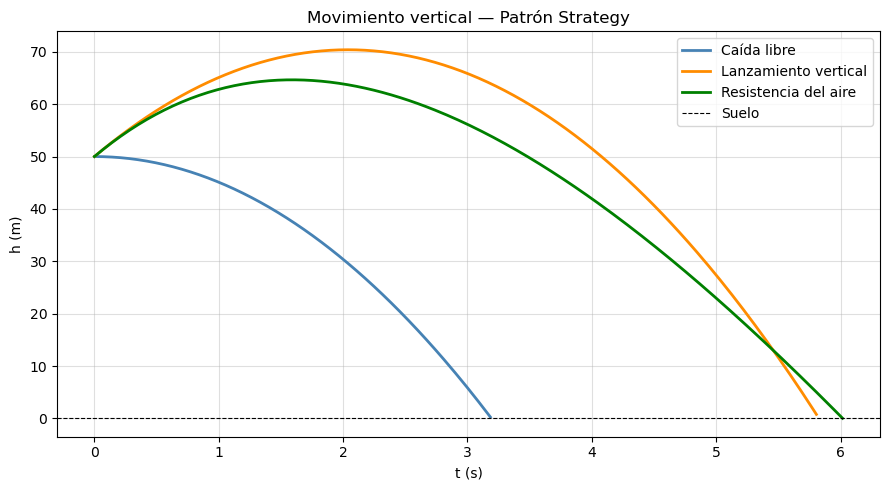

In [14]:
from abc import ABC, abstractmethod
import math, numpy as np, matplotlib.pyplot as plt

G = 9.81  # aceleración gravitacional en m/s²

# ── Interfaz (contrato que todas las estrategias deben cumplir) ───────────────
class EstrategiaMovimiento(ABC):
    @abstractmethod
    def calcular_altura(self, h0, v0, masa, t): pass

    @property
    @abstractmethod
    def nombre(self): pass


# ── Estrategias concretas (cada una implementa el contrato) ──────────────────
class CaidaLibre(EstrategiaMovimiento):
    nombre = "Caída libre"
    def calcular_altura(self, h0, v0, masa, t):
        """Sin velocidad inicial. h(t) = h₀ - ½g·t²"""
        return h0 - 0.5 * G * t**2

class LanzamientoVertical(EstrategiaMovimiento):
    nombre = "Lanzamiento vertical"
    def calcular_altura(self, h0, v0, masa, t):
        """Con velocidad inicial. h(t) = h₀ + v₀·t - ½g·t²"""
        return h0 + v0*t - 0.5*G*t**2

class ConResistenciaAire(EstrategiaMovimiento):
    nombre = "Con resistencia del aire"
    def __init__(self, k=0.2):
        self.k = k  # coeficiente de arrastre (kg/s)
    def calcular_altura(self, h0, v0, masa, t):
        """Aproximación con fuerza de arrastre proporcional a la velocidad."""
        k, m = self.k, masa
        return h0 + (m/k)*(v0 + m*G/k)*(1 - math.exp(-k*t/m)) - (m*G/k)*t


# ── Contexto: objeto físico que delega en una estrategia ─────────────────────
class ObjetoFisico:
    """
    Contexto del patrón Strategy.
    No sabe cómo calcular alturas: lo delega en la estrategia asignada.
    """

    def __init__(self, nombre, masa, h0, v0):
        self.nombre = nombre
        self.masa, self.h0, self.v0 = masa, h0, v0
        self._estrategia = None

    def set_estrategia(self, e: EstrategiaMovimiento):
        """Cambia el algoritmo en tiempo de ejecución."""
        self._estrategia = e

    def altura_en(self, t):
        """Delega el cálculo a la estrategia actual."""
        if self._estrategia is None:
            raise RuntimeError("No se ha asignado una estrategia.")
        return self._estrategia.calcular_altura(self.h0, self.v0, self.masa, t)


# ── Simulación y gráfica ──────────────────────────────────────────────────────
pelota = ObjetoFisico("Pelota", masa=1.0, h0=50.0, v0=20.0)

fig, ax = plt.subplots(figsize=(9, 5))
estrategias = [
    (CaidaLibre(),               "Caída libre",           "steelblue"),
    (LanzamientoVertical(),      "Lanzamiento vertical",  "darkorange"),
    (ConResistenciaAire(k=0.3), "Resistencia del aire",  "green"),
]

for est, etq, color in estrategias:
    pelota.set_estrategia(est)   # cambiamos el algoritmo
    ts = np.linspace(0, 7, 300)
    hs = []
    for t in ts:
        h = pelota.altura_en(t)
        if h < 0 and hs: break  # detener al tocar el suelo
        hs.append(max(h, 0))
    ax.plot(ts[:len(hs)], hs, label=etq, color=color, lw=2)

ax.axhline(0, color="k", lw=0.8, ls="--", label="Suelo")
ax.set_xlabel("t (s)"); ax.set_ylabel("h (m)")
ax.set_title("Movimiento vertical — Patrón Strategy")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### 5.4 Observer — notificación automática de cambios

**Problema:** un objeto cambia de estado y varios objetos distintos
necesitan reaccionar a ese cambio. Si cada uno sondea constantemente
(*polling*) para ver si algo cambió, es ineficiente.

**Solución:** el objeto que cambia (el **sujeto** o *subject*)
mantiene una lista de **observadores**. Cuando cambia, los notifica.

```
EstacionMeteorologica   ← sujeto: publica mediciones
    registrar(obs)      ← añade un observador
    set_mediciones(...) ← cambia datos y notifica a todos

Observadores registrados:
    PantallaActual      ← muestra la lectura en tiempo real
    Estadisticas        ← calcula min, max, promedio histórico
    AlertaCalor         ← avisa si la temperatura supera un umbral
```

**Ventaja:** para añadir una nueva reacción (por ejemplo, enviar un correo),
basta con crear un nuevo observador y registrarlo. No hay que tocar el sujeto.

In [15]:
from abc import ABC, abstractmethod
import random
import emoji #https://pypi.org/project/emoji/

# ── Interfaz de observador ────────────────────────────────────────────────────
class Observador(ABC):
    @abstractmethod
    def actualizar(self, sujeto): pass

# ── Sujeto ────────────────────────────────────────────────────────────────────
class EstacionMeteorologica:
    """
    Sujeto del patrón Observer.
    Mantiene una lista de observadores y los notifica cuando cambian los datos.
    """

    def __init__(self):
        self._observadores = []
        self.temperatura = self.humedad = self.presion = 0

    def registrar(self, obs):
        """Añade un observador a la lista."""
        self._observadores.append(obs)

    def desregistrar(self, obs):
        """Elimina un observador (deja de recibir notificaciones)."""
        self._observadores.remove(obs)

    def _notificar(self):
        """Privado: llama a actualizar() en cada observador registrado."""
        for obs in self._observadores:
            obs.actualizar(self)  # polimorfismo: cada uno reacciona distinto

    def set_mediciones(self, temp, hum, pres):
        """Actualiza los datos y notifica automáticamente."""
        self.temperatura, self.humedad, self.presion = temp, hum, pres
        self._notificar()

# ── Observadores concretos ────────────────────────────────────────────────────
class PantallaActual(Observador):
    """Muestra la lectura más reciente."""
    def actualizar(self, e):
        print(f"  [Pantalla]   T={e.temperatura:.1f}°C  H={e.humedad:.0f}%  P={e.presion:.0f} hPa")

class Estadisticas(Observador):
    """Acumula histórico y muestra min, max y promedio."""
    def __init__(self): self._temps = []
    def actualizar(self, e):
        self._temps.append(e.temperatura)
        print(f"  [Estadísticas] min={min(self._temps):.1f}  "
              f"max={max(self._temps):.1f}  "
              f"avg={sum(self._temps)/len(self._temps):.1f} °C")

class AlertaCalor(Observador):
    """Lanza alerta si la temperatura supera el umbral definido."""
    def __init__(self, umbral=33): self.umbral = umbral
    def actualizar(self, e):
        if e.temperatura > self.umbral:
            print(f"  {emoji.emojize(':warning:')} [ALERTA] Temperatura alta: {e.temperatura:.1f}°C (umbral={self.umbral}°C)")


# ── Simulación ────────────────────────────────────────────────────────────────
estacion = EstacionMeteorologica()
estacion.registrar(PantallaActual())
estacion.registrar(Estadisticas())
estacion.registrar(AlertaCalor(umbral=33))

random.seed(42)
print("=== Simulación de 5 lecturas ===")
for i in range(5):
    t = round(random.uniform(25, 38), 1)
    h = round(random.uniform(40, 80), 0)
    p = round(random.uniform(1005, 1015), 0)
    print(f"\nLectura {i+1}:")
    estacion.set_mediciones(t, h, p)



=== Simulación de 5 lecturas ===

Lectura 1:
  [Pantalla]   T=33.3°C  H=41%  P=1008 hPa
  [Estadísticas] min=33.3  max=33.3  avg=33.3 °C
  ⚠️ [ALERTA] Temperatura alta: 33.3°C (umbral=33°C)

Lectura 2:
  [Pantalla]   T=27.9°C  H=69%  P=1012 hPa
  [Estadísticas] min=27.9  max=33.3  avg=30.6 °C

Lectura 3:
  [Pantalla]   T=36.6°C  H=43%  P=1009 hPa
  [Estadísticas] min=27.9  max=36.6  avg=32.6 °C
  ⚠️ [ALERTA] Temperatura alta: 36.6°C (umbral=33°C)

Lectura 4:
  [Pantalla]   T=25.4°C  H=49%  P=1010 hPa
  [Estadísticas] min=25.4  max=36.6  avg=30.8 °C

Lectura 5:
  [Pantalla]   T=25.3°C  H=48%  P=1011 hPa
  [Estadísticas] min=25.3  max=36.6  avg=29.7 °C


---
## 6. Módulos y paquetes

### 6.1 ¿Qué es un módulo?

Un **módulo** es simplemente un archivo `.py`.
Cualquier archivo de Python con funciones y clases puede ser importado
desde otro archivo.

```python
import mi_modulo          # importar todo el módulo
from mi_modulo import X   # importar solo X
import mi_modulo as mm    # importar con alias
```

### 6.2 ¿Qué es un paquete?

Un **paquete** es una carpeta que contiene varios módulos y
un archivo especial `__init__.py`.

El archivo `__init__.py` le dice a Python «esta carpeta es un paquete».
Puede estar vacío o contener código que se ejecuta al importar el paquete.

```
mi_fisica/              ← carpeta = paquete
├── __init__.py         ← obligatorio para que Python lo reconozca
└── vectores.py         ← módulo dentro del paquete
```

Para importar: `from mi_fisica import Vector`

El prefijo `.` en `from .vectores import Vector` dentro de `__init__.py`
significa «importar desde este mismo paquete» (importación relativa).

In [16]:
import os
os.makedirs("mi_fisica", exist_ok=True)

In [17]:
%%writefile mi_fisica/vectores.py
"""Módulo con la clase Vector y funciones auxiliares."""
import math

class Vector:
    """Vector 2D/3D con operaciones básicas."""
    def __init__(self, x, y, z=0):
        self.x, self.y, self.z = x, y, z
    def __add__(self, o): return Vector(self.x+o.x, self.y+o.y, self.z+o.z)
    def __abs__(self):    return math.sqrt(self.x**2+self.y**2+self.z**2)
    def __str__(self):    return f"({self.x}, {self.y}, {self.z})"

def angulo_entre(v1, v2):
    """Ángulo en grados entre dos vectores."""
    cos_a = (v1.x*v2.x+v1.y*v2.y+v1.z*v2.z) / (abs(v1)*abs(v2))
    return math.degrees(math.acos(max(-1, min(1, cos_a))))

Overwriting mi_fisica/vectores.py


In [18]:
%%writefile mi_fisica/__init__.py
"""Paquete mi_fisica: herramientas para física computacional."""
# La importación relativa (.vectores) significa: busca en esta misma carpeta
from .vectores import Vector, angulo_entre

Overwriting mi_fisica/__init__.py


In [19]:
# Recargar el paquete si ya fue importado en esta sesión
import importlib, sys
for mod in list(sys.modules):
    if "mi_fisica" in mod: del sys.modules[mod]

from mi_fisica import Vector, angulo_entre

v1 = Vector(1, 0, 0)   # vector unitario en x
v2 = Vector(0, 1, 0)   # vector unitario en y
print("v1:", v1)
print("v2:", v2)
print("v1 + v2:", v1 + v2)
print(f"Ángulo entre v1 y v2: {angulo_entre(v1, v2):.1f}°")  # debe ser 90°

v1: (1, 0, 0)
v2: (0, 1, 0)
v1 + v2: (1, 1, 0)
Ángulo entre v1 y v2: 90.0°


---
## 7. Buenas prácticas — Principios SOLID

SOLID es un acrónimo de cinco principios de diseño OOP que hacen el código
más **mantenible**, **extensible** y **comprensible**.

Fueron popularizados por Robert C. Martin ("Uncle Bob") y son la base
del diseño profesional de software.

| Letra | Nombre completo | Idea central |
|-------|------------------|--------------|
| **S** | Single Responsibility | Una clase = una sola razón para cambiar |
| **O** | Open/Closed | Extensión sin modificación del código existente |
| **L** | Liskov Substitution | Subclase puede reemplazar a superclase sin romper nada |
| **I** | Interface Segregation | Mejor muchas interfaces pequeñas que una grande |
| **D** | Dependency Inversion | Depender de abstracciones, no de implementaciones concretas |

### S — Responsabilidad Única (Single Responsibility Principle)

**Idea:** cada clase debe tener **una sola responsabilidad**,
es decir, una sola razón para cambiar.

Si una clase calcula *y* imprime *y* guarda en disco,
tiene tres razones para cambiar (si cambia el formato de impresión,
si cambia el formato de archivo, si cambia el cálculo).
Eso la hace frágil y difícil de mantener.

In [20]:
#  MAL: ReporteMAL tiene demasiadas responsabilidades
class ReporteMAL:
    def __init__(self, datos):   self.datos = datos
    def calcular(self):          return sum(self.datos)
    def imprimir(self):          print("Total:", self.calcular())
    def guardar_csv(self, ruta): open(ruta,"w").write(str(self.calcular()))
    # Problema: si cambia el formato CSV, tengo que tocar la clase Reporte
    # Si cambia cómo se imprime, también. Tres razones para cambiar.

# BIEN: cada clase tiene UNA sola responsabilidad
class Reporte:
    """Responsabilidad: calcular datos."""
    def __init__(self, datos): self.datos = datos
    def total(self): return sum(self.datos)

class ImpresoraReporte:
    """Responsabilidad: presentar el reporte en pantalla."""
    def imprimir(self, r):
        print(f"Total del reporte: {r.total()}")

class ExportadorCSV:
    """Responsabilidad: guardar en disco."""
    def guardar(self, r, ruta):
        with open(ruta, "w") as f: f.write(f"total,{r.total()}\n")
        print(f"Guardado en {ruta}")


r = Reporte([100, 200, 300])
ImpresoraReporte().imprimir(r)
ExportadorCSV().guardar(r, "rep.csv")

Total del reporte: 600
Guardado en rep.csv


### O — Abierto/Cerrado (Open/Closed Principle)

**Idea:** el código debe estar **abierto para extensión** pero
**cerrado para modificación**.

Debes poder añadir nueva funcionalidad **sin tocar el código que ya funciona**.
Esto previene introducir errores en código que ya fue probado.

La forma más común de lograrlo es usando herencia y clases abstractas:
cada nuevo comportamiento va en una nueva clase.

In [21]:
from abc import ABC, abstractmethod

class Descuento(ABC):
    @abstractmethod
    def aplicar(self, precio): pass

class SinDescuento(Descuento):
    def aplicar(self, precio): return precio

class Descuento10(Descuento):
    def aplicar(self, precio): return precio * 0.90

class DescuentoNavidad(Descuento):   # ← extensión sin tocar nada anterior
    def aplicar(self, precio): return precio * 0.75

def precio_final(base, descuento: Descuento):
    """
    Esta función NUNCA cambia aunque añadamos nuevos descuentos.
    Está cerrada para modificación, abierta para extensión.
    """
    return descuento.aplicar(base)


for d in [SinDescuento(), Descuento10(), DescuentoNavidad()]:
    print(f"{type(d).__name__:20s}: ${precio_final(100, d):.2f}")

SinDescuento        : $100.00
Descuento10         : $90.00
DescuentoNavidad    : $75.00


### L — Sustitución de Liskov (Liskov Substitution Principle)

**Idea:** si `B` es subclase de `A`, entonces cualquier lugar del código
que usa un objeto `A` debe funcionar correctamente con un objeto `B`,
sin sorpresas ni errores.

En términos simples: una subclase debe **comportarse igual** que su superclase
en todos los contextos en que la superclase se usa.

Esto se viola cuando una subclase hace cosas inesperadas
(por ejemplo, lanza excepciones que la superclase no lanza,
o devuelve tipos incompatibles).

In [22]:
from abc import ABC, abstractmethod
import math

class Forma(ABC):
    @abstractmethod
    def area(self) -> float: pass

class Circulo(Forma):
    def __init__(self, r): self.r = r
    def area(self): return math.pi * self.r**2

class Cuadrado(Forma):
    def __init__(self, lado): self.lado = lado
    def area(self): return self.lado**2

# Esta función acepta CUALQUIER Forma.
# Funciona igual con Circulo o Cuadrado → LSP garantizado.
# Si mañana añadimos Triangulo(Forma), también funcionará aquí.
def imprimir_area(forma: Forma):
    print(f"  {type(forma).__name__:12s}: {forma.area():.3f}")

for f in [Circulo(3), Cuadrado(4), Circulo(1)]:
    imprimir_area(f)

  Circulo     : 28.274
  Cuadrado    : 16.000
  Circulo     : 3.142


### D — Inversión de Dependencias (Dependency Inversion Principle)

**Idea:** las clases de alto nivel no deben depender de las clases de bajo nivel.
Ambas deben depender de **abstracciones** (clases abstractas o interfaces).

```
MAL: Notificador → Email        (acoplado a Email concreto)
BIEN: Notificador → Canal (ABC)  (desacoplado)
                └── Email : Canal
                └── SMS   : Canal
                └── Push  : Canal
```

El «truco» es la **inyección de dependencias**: en lugar de crear el objeto
dentro de la clase, se lo pasamos desde fuera. Así podemos cambiar la
implementación sin tocar la clase que la usa.

In [23]:
from abc import ABC, abstractmethod

# ── Abstracción (interfaz) ────────────────────────────────────────────────────
class Canal(ABC):
    @abstractmethod
    def enviar(self, mensaje): pass

# ── Implementaciones concretas ────────────────────────────────────────────────
class Email(Canal):
    def enviar(self, m): print(f"{emoji.emojize(':e-mail:')}  Email: {m}")

class SMS(Canal):
    def enviar(self, m): print(f"{emoji.emojize(':mobile_phone:')} SMS: {m}")

class Push(Canal):
    def enviar(self, m): print(f"{emoji.emojize(':bell:')} Push: {m}")

# ── Clase de alto nivel: depende de Canal (abstracción) ───────────────────────
class Notificador:
    """
    No sabe qué canal concreto se usa.
    El canal se inyecta desde fuera (Dependency Injection).
    Para cambiar de Email a SMS, no tocamos esta clase.
    """
    def __init__(self, canal: Canal):  # recibe la abstracción, no la concreción
        self._canal = canal

    def notificar(self, mensaje):
        self._canal.enviar(mensaje)


# El mismo Notificador funciona con cualquier Canal
for canal in [Email(), SMS(), Push()]:
    Notificador(canal).notificar("Tu pedido está listo")

📧  Email: Tu pedido está listo
📱 SMS: Tu pedido está listo
🔔 Push: Tu pedido está listo


---
## 8. Aplicación completa — Simulación física con OOP

Este ejemplo integra todos los conceptos del tema en un programa coherente:

- **Clases** para representar objetos físicos
- **Herencia y abstracción** para las estrategias de movimiento
- **Polimorfismo** para simular con distintos modelos físicos
- **Patrón Strategy** para intercambiar el algoritmo de integración
- **matplotlib** para visualizar los resultados

El escenario: una pelota lanzada desde 50 m de altura con velocidad inicial 25 m/s.
Simulamos tres modelos físicos y comparamos sus trayectorias.

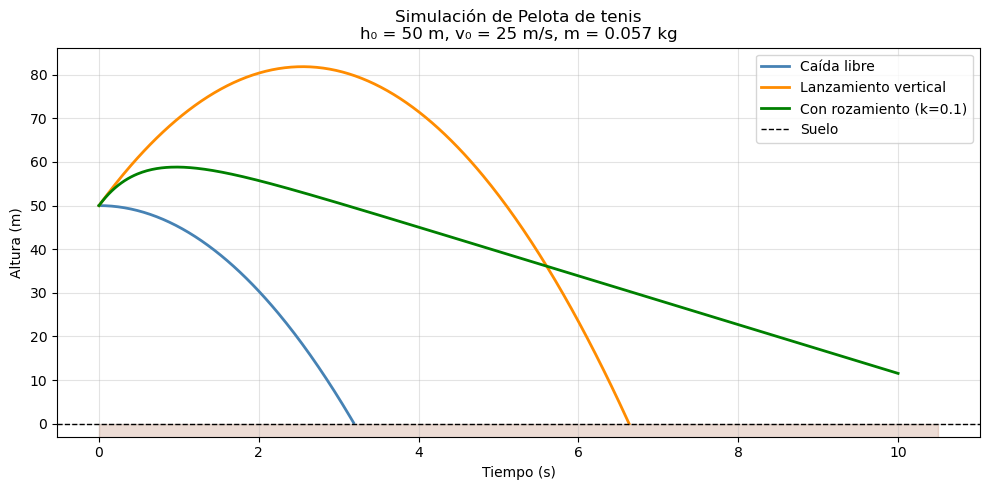

In [24]:
from abc import ABC, abstractmethod
import math, numpy as np, matplotlib.pyplot as plt

G = 9.81  # m/s²

# ── Estrategias de movimiento (Pattern Strategy) ──────────────────────────────
class Movimiento(ABC):
    @abstractmethod
    def altura(self, h0, v0, masa, t): pass

class CaidaLibre(Movimiento):
    """h(t) = h₀ - ½g·t²   (sin velocidad inicial)"""
    def altura(self, h0, v0, masa, t):
        return h0 - 0.5*G*t**2

class LanzamientoVertical(Movimiento):
    """h(t) = h₀ + v₀·t - ½g·t²   (con velocidad inicial hacia arriba)"""
    def altura(self, h0, v0, masa, t):
        return h0 + v0*t - 0.5*G*t**2

class ConRozamiento(Movimiento):
    """Modelo con resistencia del aire proporcional a la velocidad."""
    def __init__(self, k=0.2):
        self.k = k  # coeficiente de arrastre (mayor k = más rozamiento)
    def altura(self, h0, v0, masa, t):
        k, m = self.k, masa
        return h0 + (m/k)*(v0 + m*G/k)*(1 - math.exp(-k*t/m)) - (m*G/k)*t


# ── Cuerpo lanzado (contexto del Strategy) ────────────────────────────────────
class CuerpoLanzado:
    """
    Representa un objeto en movimiento vertical.
    Delega el cálculo de altura a una Estrategia de movimiento.
    """

    def __init__(self, nombre, masa, h0, v0):
        self.nombre = nombre
        self.masa, self.h0, self.v0 = masa, h0, v0

    def simular(self, movimiento: Movimiento, t_max=10, n=500):
        """
        Genera la trayectoria con el modelo dado.
        Devuelve (tiempos, alturas) hasta tocar el suelo.
        """
        ts = np.linspace(0, t_max, n)
        tiempos, alturas = [], []
        for t in ts:
            h = movimiento.altura(self.h0, self.v0, self.masa, t)
            if h < 0 and tiempos: break  # parar al tocar el suelo
            tiempos.append(t)
            alturas.append(max(h, 0))
        return np.array(tiempos), np.array(alturas)

    def graficar(self, movimientos, etiquetas, colores=None):
        """Grafica varias estrategias en la misma figura."""
        colores = colores or ["steelblue", "darkorange", "green", "crimson"]
        fig, ax = plt.subplots(figsize=(10, 5))
        for i, (mov, etq) in enumerate(zip(movimientos, etiquetas)):
            ts, hs = self.simular(mov)
            ax.plot(ts, hs, label=etq, color=colores[i % len(colores)], lw=2)
        ax.axhline(0, color="k", lw=1, ls="--", label="Suelo")
        ax.fill_between([0, ax.get_xlim()[1]], 0, -5, color="sienna", alpha=0.2)
        ax.set_ylim(bottom=-3)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Altura (m)")
        ax.set_title(
            f"Simulación de {self.nombre}\n"
            f"h₀ = {self.h0} m, v₀ = {self.v0} m/s, m = {self.masa} kg"
        )
        ax.legend()
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.show()


# ── Ejecutar la simulación ────────────────────────────────────────────────────
pelota = CuerpoLanzado("Pelota de tenis", masa=0.057, h0=50, v0=25)

pelota.graficar(
    movimientos = [CaidaLibre(), LanzamientoVertical(), ConRozamiento(k=0.1)],
    etiquetas   = ["Caída libre", "Lanzamiento vertical", "Con rozamiento (k=0.1)"]
)


## 9. Resumen consolidado

### Mapa conceptual final

```
CLASE                          OBJETO
─────                          ──────
class MiClase:                 obj = MiClase(args)      ← __init__ se ejecuta
    def __init__(self, x):     obj.x                    ← acceder a atributo
        self.x = x             obj.metodo()             ← llamar a método
    def metodo(self):
        ...

ENCAPSULAMIENTO                HERENCIA
───────────────                ────────
atributo      → público        class Hija(Madre):       ← hereda todo
_atributo     → protegido          super().__init__()   ← llama a madre
__atributo    → privado            def metodo(self):    ← sobreescribe
@property     → getter/setter

ABSTRACCIÓN                    POLIMORFISMO
───────────                    ────────────
from abc import ABC            def f(obj: Base):        ← acepta subclases
class Base(ABC):                   obj.metodo()         ← cada una responde
    @abstractmethod            isinstance(x, Base)      ← verificar jerarquía
    def metodo(self): pass

PATRONES                       SOLID
────────                       ─────
Singleton   → una instancia    S: una clase, una razón para cambiar
Factory     → crear sin        O: extensión sin modificación
              clase exacta     L: subclase sustituye a superclase
Strategy    → algoritmos       I: interfaces pequeñas y focalizadas
              intercambiables  D: depender de abstracciones
Observer    → notificación
              automática
```

### Cuándo usar cada herramienta

| Situación | Herramienta recomendada |
|-----------|------------------------|
| Agrupar datos y comportamiento relacionados | Clase |
| Necesito `print(obj)` legible | `__str__` |
| Quiero que `obj + otro` funcione | `__add__` |
| Proteger datos de modificación no autorizada | `@property` + atributo `__privado` |
| Reutilizar código entre clases relacionadas | Herencia + `super()` |
| Definir un contrato que las subclases deben cumplir | `ABC` + `@abstractmethod` |
| Una sola instancia global | Singleton |
| Crear objetos sin acoplarse a la clase concreta | Factory Method |
| Algoritmo intercambiable en tiempo de ejecución | Strategy |
| Notificar cambios a múltiples objetos | Observer |
| Separar código en archivos reutilizables | Módulos y paquetes |

---

## Referencias

1. Lutz, M. *Learning Python*. O'Reilly, 2013.
2. Ramalho, L. *Fluent Python* (2.ª ed.). O'Reilly, 2022.
3. Martin, R. C. *Clean Code*. Prentice Hall, 2008.
4. Gamma, E. et al. *Design Patterns*. Addison-Wesley, 1994.
5. Documentación oficial Python — módulo `abc`: https://docs.python.org/3/library/abc.html
6. Lista completa de métodos dunder: https://www.pythonmorsels.com/every-dunder-method/